# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Implement the Monte-Carlo method to approximate the integral in the lesson
Note that the default values of N and sx are 10000 and 0.75. You will change these in the quizzes but may need to change them back to their default values at some point.

In [15]:
N = 10000; sx = 0.75;     % problem constants
N = 25000;
# sx = 1.0;

trueMean = exp(-sx^2/2);  % Found by closed-form integration techniques

% Standard Monte-Carlo approach
randn("state",0);
x = sx*randn(1,N);        % generate sample pts.
y = cos(x);               % function evaluations
muEst1 = cumsum(y)./(1:N); % running approx. using Monte-Carlo method

In [16]:
% Monte-Carlo with importance density approach (uniform distribution)
rand("state",1);
q = 8*sx*(rand([1 N])-0.5);
y = cos(q).*exp(-q.^2/(2*sx^2))/sqrt(2*pi*sx^2)/(1/(8*sx));
muEst2 = cumsum(y)./(1:N);

### Plot results

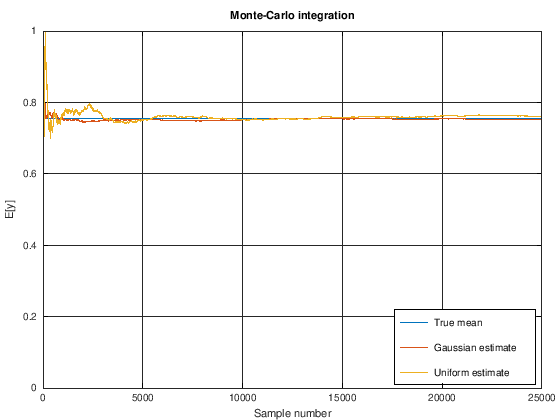

In [17]:
plot([0 N-1],trueMean*[1 1],0:N-1,muEst1,0:N-1,muEst2);
legend('True mean','Gaussian estimate','Uniform estimate','location','southeast');
xlabel('Sample number');
ylabel('E[y]'); ylim([0 1]); grid on
title('Monte-Carlo integration');

In [18]:
rmse = rms(trueMean-muEst1(end-1999:end));
fprintf('RMSE over final 2000 iterations for standard Monte-Carlo method is: %g\n',rmse)

rmse = rms(trueMean-muEst2(end-1999:end));
fprintf('RMSE over final 2000 iterations for (Monte-Carlo with) importance-density method is: %g\n',rmse)

RMSE over final 2000 iterations for standard Monte-Carlo method is: 0.00173161
RMSE over final 2000 iterations for (Monte-Carlo with) importance-density method is: 0.00741103
